In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ripser import ripser
from persim import plot_diagrams

from scipy.cluster.hierarchy import linkage, to_tree
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import dendrogram, set_link_color_palette

# **Holografía Jerárquica**

In [39]:
#Función para calcular las matrices de Lance-Williams (LW)
def matrices_LW(X, method='complete'):
    #Calcular la primera matriz de distancias
    d_mat = squareform(pdist(X)).astype(float)
    c_sizes = np.ones(d_mat.shape[0])
    matrices = [d_mat.copy()]

    while d_mat.shape[0] > 2:
        m = d_mat.copy()
        np.fill_diagonal(m, np.inf)
        #Minima distancia
        min_val = np.min(m)
        if np.isinf(min_val): break

        # Encontrar todos las entradas cuya distancia sea la minima (clusters a fusionar)
        i_idx, j_idx = np.where(np.isclose(d_mat, min_val))

        #Fusionar clusters
        G = nx.Graph()
        G.add_nodes_from(range(d_mat.shape[0]))
        for i, j in zip(i_idx, j_idx):
            G.add_edge(i, j)

        components = [list(c) for c in nx.connected_components(G)]
        new_clusters = []

        for comp in components:
            new_clusters.append(comp)

        # Construir la siguiente matriz de distancia en base a la regla de iteración LW
        new_n = len(new_clusters)
        if new_n == d_mat.shape[0]: break

        new_d_mat = np.zeros((new_n, new_n))
        new_sizes = np.zeros(new_n)

        for i in range(new_n):
            new_sizes[i] = np.sum(c_sizes[new_clusters[i]])
            for j in range(i + 1, new_n):
                c1, c2 = new_clusters[i], new_clusters[j]

                if method == 'single':
                    d_val = np.min(d_mat[np.ix_(c1, c2)])
                elif method == 'complete':
                    d_val = np.max(d_mat[np.ix_(c1, c2)])
                elif method == 'average':
                    d_val = np.mean(d_mat[np.ix_(c1, c2)])
                    
                new_d_mat[i, j] = new_d_mat[j, i] = d_val

        d_mat = new_d_mat
        matrices.append(d_mat.copy())

    return matrices

#Funcion para obtener la holografía jerárquica a partir de las matrices LW
def holografia(mats, maxDim=1):
    #mats son las matrices LW
    n = len(mats)
    if n == 1: axes = [axes]

    diagramas=[]
    num_clusters=[]
    #Calcular el diagrama de persistencia para cada matriz LW
    for i, m in enumerate(mats):
        dgms = ripser(m, distance_matrix=True, maxdim=maxDim)['dgms']
        diagramas.append(dgms)
        num_clusters.append(m.shape[0])

    return diagramas, num_clusters

#Funcion para obtener el clustering aglomerativo LW
def aglomerativo_LW(X, method='complete'):
    n_orig = len(X)
    d_mat = squareform(pdist(X)).astype(float)
    c_sizes = np.ones(n_orig)

    current_ids = np.arange(n_orig)
    next_id = n_orig
    Z = []

    while d_mat.shape[0] > 1:
        m = d_mat.copy()
        np.fill_diagonal(m, np.inf)
        min_val = np.min(m)
        if np.isinf(min_val): break

        i_idx, j_idx = np.where(np.isclose(d_mat, min_val))
        G = nx.Graph()
        G.add_nodes_from(range(d_mat.shape[0]))
        for i, j in zip(i_idx, j_idx):
            G.add_edge(i, j)

        components = [list(c) for c in nx.connected_components(G)]
        new_ids = []
        new_n = len(components)

        new_d_mat = np.zeros((new_n, new_n))
        new_sizes = np.zeros(new_n)

        for idx, comp in enumerate(components):
            if len(comp) > 1:
                root_id = current_ids[comp[0]]
                root_size = c_sizes[comp[0]]
                for k in range(1, len(comp)):
                    leaf_id = current_ids[comp[k]]
                    leaf_size = c_sizes[comp[k]]
                    Z.append([float(root_id), float(leaf_id), float(min_val), float(root_size + leaf_size)])
                    root_id = next_id
                    root_size += leaf_size
                    next_id += 1
                new_ids.append(root_id)
            else:
                new_ids.append(current_ids[comp[0]])

        for i in range(new_n):
            c1 = components[i]
            new_sizes[i] = np.sum(c_sizes[c1])
            for j in range(i + 1, new_n):
                c2 = components[j]
                if method == 'single': d_val = np.min(d_mat[np.ix_(c1, c2)])
                elif method == 'complete': d_val = np.max(d_mat[np.ix_(c1, c2)])
                elif method == 'average': d_val = np.mean(d_mat[np.ix_(c1, c2)])
                else: d_val = np.mean(d_mat[np.ix_(c1, c2)])
                new_d_mat[i, j] = new_d_mat[j, i] = d_val

        d_mat = new_d_mat
        c_sizes = new_sizes
        current_ids = np.array(new_ids)

    return np.array(Z)

#Función para graficar el diagrama de persistencia
def graficar_diag(dgms,titulo, guardado):
  fig, ax = plt.subplots(figsize=(7, 7))

  max_val = max([np.nanmax(d[np.isfinite(d)]) for d in dgms if d.size > 0]) * 1.1
  ax.plot([0, max_val], [0, max_val], '--', color='black', alpha=1)

  x_vals = np.linspace(0, max_val, 100)
  ax.fill_between(x_vals, 0, x_vals, color='lightgray', alpha=0.8)

  colors = ['#2AA58B', '#804C80', '#D6AF51', '#c0392b']
  labels = ['$H_0$', '$H_1$', '$H_2$', '$H_3$']

  for i, dgm in enumerate(dgms):
      if dgm.size > 0:
          clean_dgm = dgm[np.isfinite(dgm).all(axis=1)]

          ax.scatter(clean_dgm[:, 0], clean_dgm[:, 1],
                    color=colors[i],
                    label=labels[i],
                    s=80,
                    alpha=0.8,
                    edgecolors='none')

  ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
  ax.set_xlim(-0.03*max_val, max_val)
  ax.set_ylim(0, max_val)
  ax.set_xlabel('Nacimiento', fontsize=15)
  ax.set_ylabel('Muerte', fontsize=15)
  ax.set_title(f'{titulo}', fontsize=15)
  ax.legend()
  plt.savefig(f'{guardado}', bbox_inches='tight')
  plt.show()

# **Ejemplo Anillo con Ruido Central**

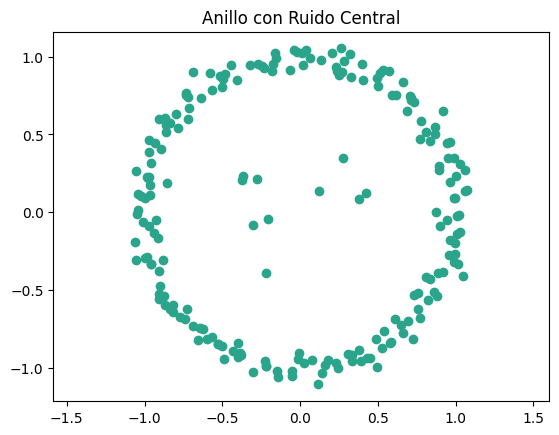

In [40]:
n_points = 200
theta = np.linspace(0, 2*np.pi, n_points)
r = 1.0
ring = np.array([r * np.cos(theta), r * np.sin(theta)]).T
ring += np.random.normal(0, 0.05, ring.shape)

n_noise = 10
noise = np.random.uniform(-0.5, 0.5, (n_noise, 2))

X = np.vstack([ring, noise])

plt.figure()
plt.scatter(X[:,0],X[:,1],color='#2AA58B')
plt.axis('equal')
plt.title('Anillo con Ruido Central')
plt.savefig('Anillo con Ruido Central.png', bbox_inches='tight')
plt.show()

In [41]:
mats=matrices_LW(X, method='complete')

holog,num_clusters=holografia(mats, maxDim=1)

In [ ]:
for t in range(len(holog)):
    graficar_diag(holog[t], titulo=f'Paso {t} \n Número de clusters={num_clusters[t]}')

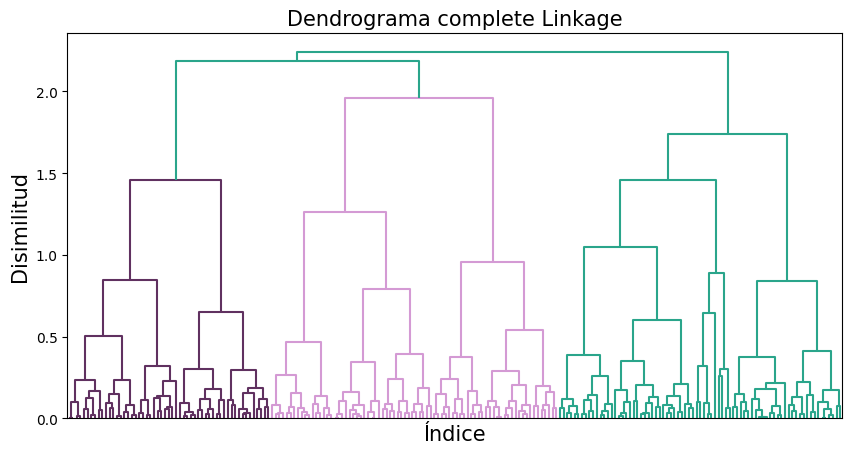

In [45]:
Z=aglomerativo_LW(X, method='complete')

plt.figure(figsize=(10, 5))
plt.title('Dendrograma complete Linkage',fontsize=15)
plt.xlabel('Índice',fontsize=15)
plt.ylabel('Disimilitud',fontsize=15)
colores = ['#603160', '#D49AD4', '#2AA58B', '#AEEEE2']
set_link_color_palette(colores)
#umbral para realizar la distinción por colores
umbral_manual = 2
color_final = colores[2]
dendro = dendrogram(Z, no_labels=True, leaf_font_size=11, color_threshold=umbral_manual, above_threshold_color=color_final)
plt.savefig('Dendrograma complete Linkage.png', bbox_inches='tight')
plt.show()